In [ ]:
!pip install graphviz 

'''micro grad auto grad back propogation -efficientlu gradient loss and tunes weight and less loss function'''

In [43]:
pip install micrograd

Note: you may need to restart the kernel to use updated packages.


In [44]:
from micrograd.engine import Value
a=Value(-4.0)
b=Value(2.0)
c=a+b
d=a*b+b**3
c+= c+1
c+= 1+c+(-a)
d+= d*2+(b+a).relu()
d+=3*d+(b-a).relu()
e=c-d
f=e**2
g=f/2.0
g+=10.0/f
print(f'{g.data:.4f}')#forward padd
g.backward()
print(f'{a.grad:.4f}')#dg/da
print(f'{b.grad:.4f}')#dg/db how a and b is effecting a is 138 and make a large as slope is 138 



24.7041
138.8338
645.5773


In [45]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
def f(x):
    return 3*x**2-4*x+5

In [47]:
f(3.0)

20.0

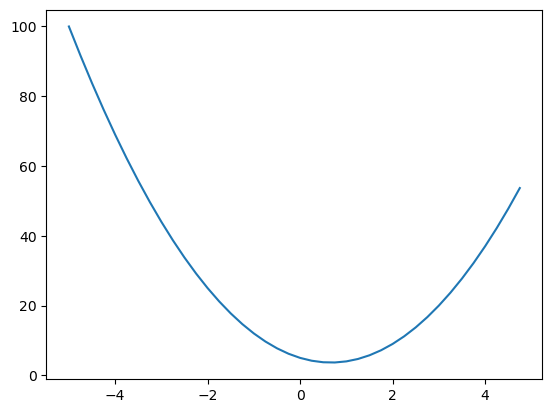

In [48]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
ys
plt.plot(xs,ys)
plt.show()

In [49]:
# we ar eonfing the derivate at any point in the x axis and y according to the derivate formula we are bumpinf thw x value with H

h=0.0000001
x=2/3
(f(x+h)-f(x))/h #gets slope

2.9753977059954195e-07

In [50]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [51]:
h=0.001
a=2.0
b=-3.0
c=10.0
d1=a*b+c
#we ewant the derivate of d wrt a
a+=h
d2=a*b+c
print(d1)
print(d2)
print((d2-d1)/h)#DIFFERENCE HOW FUNCTION BUMPED AND NORMALISED BY H TO GET SLOPE

4.0
3.997
-3.0000000000001137


In [52]:
h=0.001
a=2.0
b=-3.0
c=10.0
d1=a*b+c
#we ewant the derivate of d wrt a
b+=h
d2=a*b+c
print(d1)
print(d2)
print((d2-d1)/h)#DIFFERENCE HOW FUNCTION BUMPED AND NORMALISED BY H TO GET SLOPE

4.0
4.002
1.9999999999997797


In [53]:
h=0.001
a=2.0
b=-3.0
c=10.0
d1=a*b+c
#we ewant the derivate of d wrt a
c+=h
d2=a*b+c
print(d1)
print(d2)
print((d2-d1)/h)#DIFFERENCE HOW FUNCTION BUMPED AND NORMALISED BY H TO GET SLOPE

4.0
4.0009999999999994
0.9999999999994458


In [54]:
import math


In [66]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other): 
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [56]:
a=Value(2.0)
b=Value(4.0)
a


Value(data=2.0)

In [70]:
d._prev


AttributeError: 'float' object has no attribute '_prev'

In [ ]:
d._op

In [72]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [74]:
draw_dot(L)

NameError: name 'L' is not defined

In [ ]:
#back propogation
a.grad=-2.0*3.0
b.grad=-2.0*2.0

In [ ]:
#one ste p optimation 
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*d.grad
e = a*b
d = e + c
L = d * f
print(L.data)

In [ ]:
def lol():
    h=0.0001
    
    a = Value(2.0, label='a')
    #a.data+=h
    b = Value(-3.0, label='b')
    b.data+=h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1=L.data
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'

    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2=L.data
    print((L2-L1)/h)
lol()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#back prog in neuron
# Use np.arange and make sure it's np.tanh(np.arange(...))
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

In [76]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o=n.tanh();o.label='o'


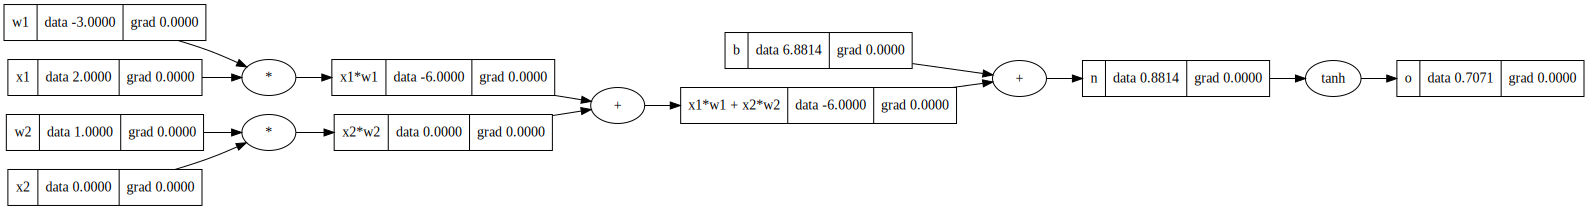

In [78]:
draw_dot(o)

In [ ]:
o.backward()

In [ ]:

x2w2._backward()
x1w1._backward()

In [ ]:
n.backward()

In [ ]:
o.grad=1.0

In [ ]:
o._backward()


In [ ]:
o.grad=1.0

In [ ]:
n.grad=0.5#do/dn=1-tanh**2 i.e o**2

In [ ]:
x1w1x2w2.grad=0.5
b.grad=0.5

In [ ]:
x1w1.grad=0.5
x2w2.grad=0.5

In [ ]:
x2.grad=w2.data*x2w2.grad
x1.grad=w1.data*x1w1.grad
w2.grad=x2.data*x2w2.grad
w2.grad=x1.data*x1w1.grad

In [80]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e=(2*n).exp()
o=(e-1)/(e+1)


#o=n.tanh();
o.label='o'
o.backward()


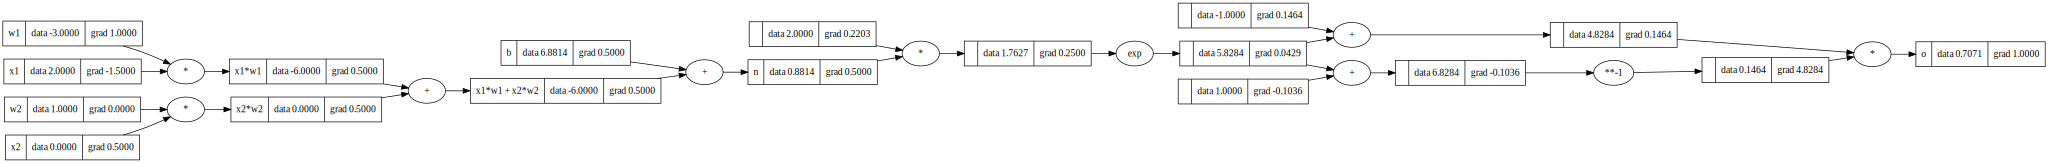

In [82]:
draw_dot(o)

In [88]:
!pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.2/114.6 MB 5.9 MB/s eta 0:00:20
   ---------------------------------------- 1.1/114.6 MB 13.7 MB/s eta 0:00:09
   - -------------------------------------- 4.8/114.6 MB 38.2 MB/s eta 0:00:03
   -- ------------------------------------- 7.8/114.6 MB 45.5 MB/s eta 0:00:03
   ---- ----------------------------------- 12.0/114.6 MB 81.8 MB/s eta 0:00:02
   ----- ---------------------------------- 16.5/114.6 MB 93.0 MB/s eta 0:00:02
   ------ -------------------------------- 19.1/114.6 MB 108.8 MB/s eta 0:00:01
   -------- ------------------------------- 23.3/114.6 MB 81.8 MB/s eta 0:00:02
   --------- ------------------------------ 26.2/114.6 MB 73.1 MB/s eta 0:00:02
   ---------- ----------------------------- 30.3/114.6 MB 81.8 MB/s eta 0:00:02
   ------------ --------------------------- 34.4/114.6 MB 81.8 MB/s eta 0:00:01
   ------------- -------------------------- 38.6/114.6

In [90]:
import torch

In [92]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [96]:
import random

In [140]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [142]:
x=[2.0,3.0,-1.0]
#n=Neuron(2)
#n=Layer(2,3)#2d layer 3 of them
n=MLP(3,[4,4,1])
n(x)

Value(data=-0.713012916708836)

In [148]:
n.parameters()

[Value(data=0.8159661720245321),
 Value(data=-0.2880989454516254),
 Value(data=-0.3402374293911248),
 Value(data=-0.18046408620972332),
 Value(data=-0.11834527285815732),
 Value(data=-0.2915324508952355),
 Value(data=-0.11710087200198438),
 Value(data=-0.16238877977701094),
 Value(data=-0.2982170716239425),
 Value(data=-0.24046468759462747),
 Value(data=0.19206234093337282),
 Value(data=0.2095350068116475),
 Value(data=-0.43664159042070416),
 Value(data=-0.8536304186832759),
 Value(data=0.5382462528827883),
 Value(data=0.6517976828709897),
 Value(data=0.3043279141893054),
 Value(data=0.793463573755933),
 Value(data=-0.28498207350231763),
 Value(data=0.5230907501314486),
 Value(data=-0.16031653052942163),
 Value(data=0.08548813248508491),
 Value(data=0.546190950572871),
 Value(data=-0.20922272457712943),
 Value(data=-0.6587662791601976),
 Value(data=-0.5864360700995357),
 Value(data=-0.330079121270743),
 Value(data=-0.14793420556595716),
 Value(data=0.9755194075200435),
 Value(data=0.11

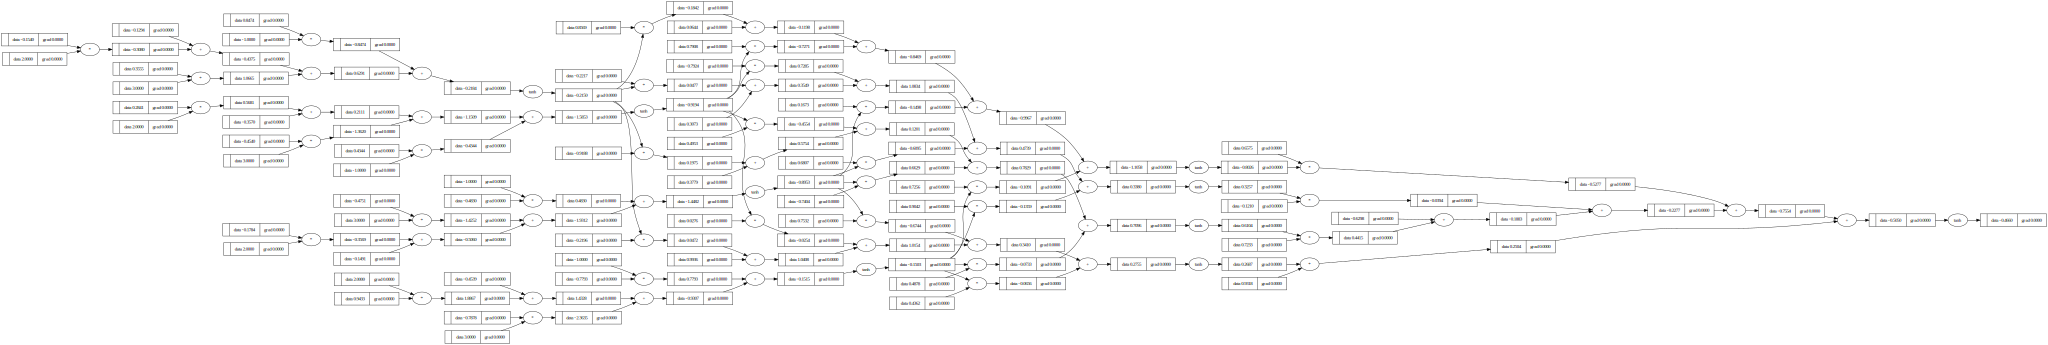

In [108]:
draw_dot(n(x))

In [324]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.2194089105289251)

In [326]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [342]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():

    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad
  
  print(k, loss.data)
  

0 0.004463938158011185
1 0.004429379651679497
2 0.004395332601584119
3 0.004361785932009286
4 0.004328728881377905
5 0.004296150991273961
6 0.004264042095919238
7 0.0042323923120831525
8 0.0042011920294050395
9 0.004170431901109162
10 0.004140102835094498
11 0.0041101959853814376
12 0.004080702743899139
13 0.004051614732597783
14 0.004022923795871007
15 0.0039946219932741655
16 0.003966701592525515
17 0.0039391550627771174
18 0.0039119750681440146
19 0.0038851544614796844


In [344]:
ypred

[Value(data=0.9727959664288014),
 Value(data=-0.9720856788721052),
 Value(data=-0.9683675856863145),
 Value(data=0.963050357788026)]